Libraries successfully imported!
Missing values processed successfully.

--- Dynamic Column Target Mapping ---
Target HDI Column: Human Development Index (2021)
Target Life Expectancy Column Found: Life Expectancy at Birth (2021)
Target Education Column Found: Expected Years of Schooling (2021)



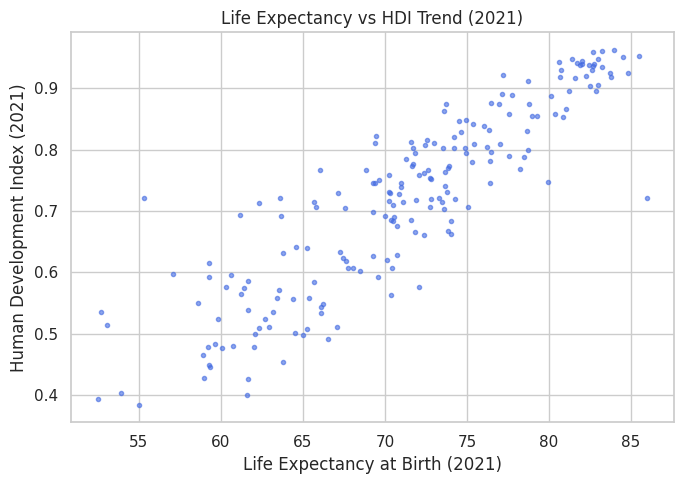

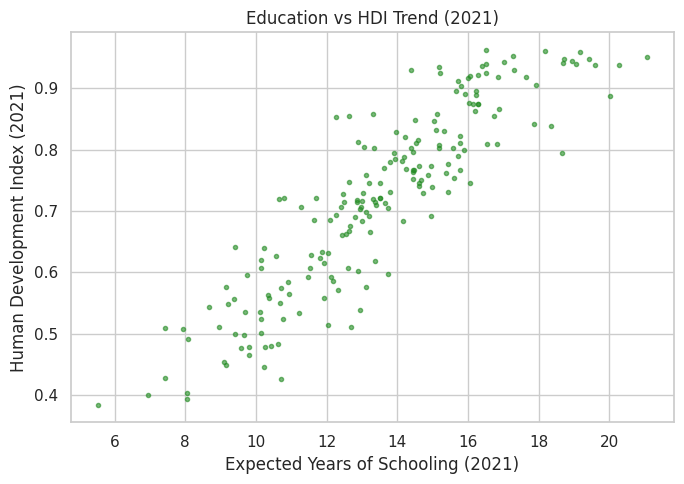


--- Process Complete! ---
Plots successfully rendered and saved to your working output dir.


In [2]:
import os
import cudf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from flask import Flask, jsonify, request

print("Libraries successfully imported!")

# ----------------------------------------------------
# STEP 1: Find and Load the Dataset Path
# ----------------------------------------------------
input_dir = "../input"
csv_filepath = None
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_filepath = os.path.join(root, file)
            break

if not csv_filepath:
    raise FileNotFoundError("No CSV file found.")

gdf = cudf.read_csv(csv_filepath)

# ----------------------------------------------------
# Task 2: Handle Missing Values on GPU
# ----------------------------------------------------
numerical_cols = gdf.select_dtypes(include=["number"]).columns
gdf[numerical_cols] = gdf[numerical_cols].astype("float64")
gdf[numerical_cols] = gdf[numerical_cols].fillna(gdf[numerical_cols].mean())
print("Missing values processed successfully.")

# ----------------------------------------------------
# Task 3: Dynamic Column Mapping Discovery
# ----------------------------------------------------
all_columns = list(gdf.columns)

# Standardize names or search for keywords matching 2021 metrics
hdi_column_name = "Human Development Index (2021)"

# Search for the columns dynamically to see what they are named
life_exp_matches = [
    c for c in all_columns if "expectancy" in c.lower() and "2021" in c
]
edu_matches = [
    c for c in all_columns if ("schooling" in c.lower() or "education" in c.lower()) and "2021" in c
]

# Fallbacks in case the specific substring search isn't exactly hit
life_exp_column_name = (
    life_exp_matches[0]
    if life_exp_matches
    else "Life expectancy at birth (years) (2021)"
)
education_column_name = (
    edu_matches[0] if edu_matches else "Expected years of schooling (years) (2021)"
)

print(f"\n--- Dynamic Column Target Mapping ---")
print(f"Target HDI Column: {hdi_column_name}")
print(f"Target Life Expectancy Column Found: {life_exp_column_name}")
print(f"Target Education Column Found: {education_column_name}\n")

# ----------------------------------------------------
# Task 4: Plot Graphs (HDI on Y-Axis) & Save Images
# ----------------------------------------------------
# Verify columns exist before pulling them to host memory
try:
    hdi_y = cudf.to_numeric(gdf[hdi_column_name], errors="coerce").to_pandas()
    life_exp_x = cudf.to_numeric(
        gdf[life_exp_column_name], errors="coerce"
    ).to_pandas()
    education_x = cudf.to_numeric(
        gdf[education_column_name], errors="coerce"
    ).to_pandas()

    sns.set_theme(style="whitegrid")

    # --- Plot 1: Life Expectancy vs HDI ---
    plt.figure(figsize=(7, 5))
    plt.scatter(life_exp_x, hdi_y, color="royalblue", marker=".", alpha=0.6)
    plt.title("Life Expectancy vs HDI Trend (2021)")
    plt.xlabel(life_exp_column_name)
    plt.ylabel(hdi_column_name)
    plt.tight_layout()
    plt.savefig("life_expectancy_vs_hdi.png", dpi=300)
    plt.show()
    plt.close()

    # --- Plot 2: Education vs HDI ---
    plt.figure(figsize=(7, 5))
    plt.scatter(education_x, hdi_y, color="forestgreen", marker=".", alpha=0.6)
    plt.title("Education vs HDI Trend (2021)")
    plt.xlabel(education_column_name)
    plt.ylabel(hdi_column_name)
    plt.tight_layout()
    plt.savefig("education_vs_hdi.png", dpi=300)
    plt.show()
    plt.close()

    print("\n--- Process Complete! ---")
    print("Plots successfully rendered and saved to your working output dir.")

except KeyError as e:
    print(f"\nKeyError: Could not locate column {e}")
    print("Available matching columns for review:")
    print("Expectancy Options:", [c for c in all_columns if "expectancy" in c.lower()][:3])
    print("Education Options:", [c for c in all_columns if "school" in c.lower()][:3])

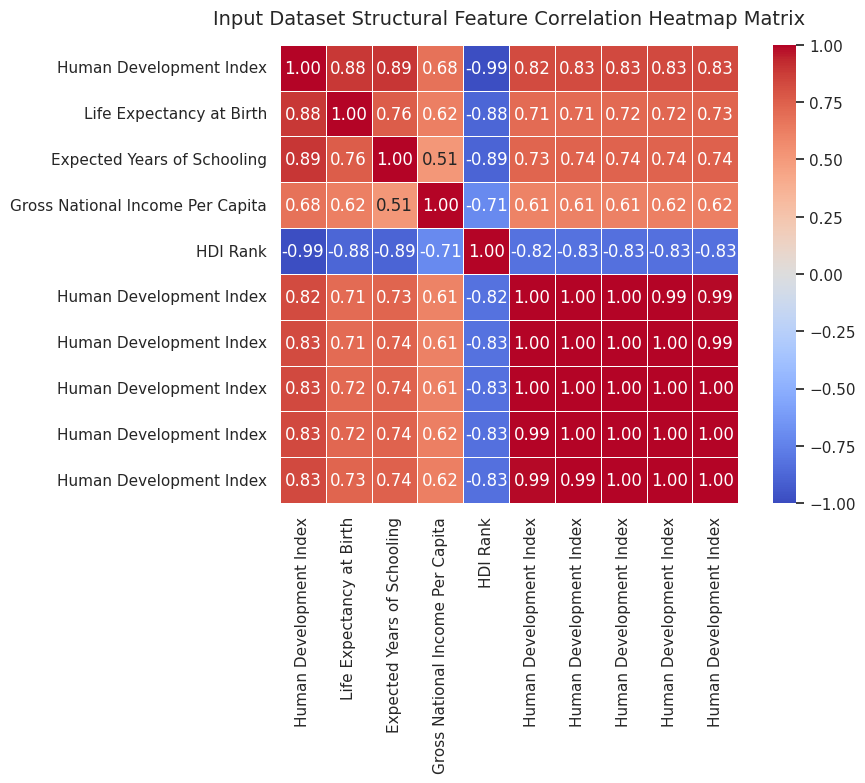


[SUCCESS] Feature correlation heatmap generated and packaged into: 'hdi_training_results.zip'


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

# 1. Gather our target verified feature columns
all_cols = list(gdf.columns)
hdi_target = [c for c in all_cols if "human development index (2021)" in c.lower()][0]
life_exp = [c for c in all_cols if "life expectancy" in c.lower() and "2021" in c][0]
edu = [c for c in all_cols if "schooling" in c.lower() and "2021" in c][0]
income = [c for c in all_cols if "gross national" in c.lower() or "gni" in c.lower() and "2021" in c]
income_col = income[0] if income else [c for c in all_cols if "income" in c.lower() and "2021" in c][0]

primary_features = [hdi_target, life_exp, edu, income_col]

# Grab the first 6 additional numerical columns to prevent visual overcrowding
secondary_features = gdf.select_dtypes(include=['number']).columns.drop(primary_features, errors='ignore')
secondary_features = list(secondary_features)[:6]

# Consolidate complete correlation subset list
correlation_features = primary_features + secondary_features

# 2. Compute correlation matrix directly on the GPU for speed
gpu_corr_matrix = gdf[correlation_features].corr()

# 3. Pull the correlation matrix to host memory for plotting
cpu_corr_matrix = gpu_corr_matrix.to_pandas()

# Clean up label names slightly for cleaner rendering in the heatmap matrix
short_names = [c.split(' (')[0] for c in correlation_features]
cpu_corr_matrix.columns = short_names
cpu_corr_matrix.index = short_names

# 4. Generate the Visualization Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cpu_corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5, 
    square=True
)
plt.title("Input Dataset Structural Feature Correlation Heatmap Matrix", fontsize=14, pad=15)
plt.tight_layout()

# Save image file to current directory
heatmap_filename = "dataset_feature_correlation_heatmap.png"
plt.savefig(heatmap_filename, dpi=300)
plt.show()
plt.close()

# 5. Re-package all deliverables to your download package
artifacts = ["confusion_matrix_heatmap.png", "loss_curve.png", heatmap_filename, "best_hybrid_hdi_model.pth", "scaling_params.pt"]
zip_filename = "hdi_training_results.zip"

with zipfile.ZipFile(zip_filename, 'w') as archive:
    for file in artifacts:
        if os.path.exists(file):
            archive.write(file)

print(f"\n[SUCCESS] Feature correlation heatmap generated and packaged into: '{zip_filename}'")

In [5]:
import cudf

# 1. Load the dataset into the GPU DataFrame
gdf = cudf.read_csv(
    "/kaggle/input/datasets/iamsouravbanerjee/human-development-index-dataset/Human Development Index - Full.csv"
)

# 2. Identify all numerical columns
num_cols = gdf.select_dtypes(include=["number"]).columns

# 3. Cast numerical columns to float64 to safely accept decimal mean values
gdf[num_cols] = gdf[num_cols].astype("float64")

# 4. Calculate means and fill missing values across the GPU
gdf[num_cols] = gdf[num_cols].fillna(gdf[num_cols].mean())

# 5. Get the first 20 unique countries
# (Using .unique() ensures uniqueness, and [:20] limits it to 20)
unique_countries = gdf["Country"].unique()[:20]

# 6. Filter the DataFrame to show only those 20 unique countries
gdf_20 = gdf[gdf["Country"].isin(unique_countries)]

# 7. Display the result
gdf_20

,ISO3,Country,Human Development Groups,UNDP Developing Regions,HDI Rank (2021),Human Development Index (1990),Human Development Index (1991),Human Development Index (1992),Human Development Index (1993),Human Development Index (1994),...,Material footprint per capita (tonnes) (2012),Material footprint per capita (tonnes) (2013),Material footprint per capita (tonnes) (2014),Material footprint per capita (tonnes) (2015),Material footprint per capita (tonnes) (2016),Material footprint per capita (tonnes) (2017),Material footprint per capita (tonnes) (2018),Material footprint per capita (tonnes) (2019),Material footprint per capita (tonnes) (2020),Material footprint per capita (tonnes) (2021)
0,AFG,Afghanistan,Low,SA,180.0,0.273000,0.279000,0.287000,0.297000,0.292000,...,1.86000,1.88000,1.660000,1.620000,1.660000,1.410000,1.32,1.38000,1.38000,1.38000
1,AGO,Angola,Medium,SSA,148.0,0.599277,0.601979,0.604525,0.608504,0.613411,...,4.09000,4.53000,3.970000,3.590000,2.790000,2.640000,2.28,2.18000,2.18000,2.18000
2,ALB,Albania,High,ECA,67.0,0.647000,0.629000,0.614000,0.617000,0.624000,...,12.44000,11.49000,13.140000,12.610000,14.390000,14.460000,12.85,12.96000,12.96000,12.96000
3,AND,Andorra,Very High,<NA>,40.0,0.599277,0.601979,0.604525,0.608504,0.613411,...,15.55535,15.67586,15.631146,15.637707,15.637834,15.798089,14.84,15.01949,15.01949,15.01949
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728000,0.739000,0.742000,0.748000,0.755000,...,49.56000,49.68000,55.490000,59.760000,64.950000,75.610000,65.97,68.95000,68.95000,68.95000
5,ARG,Argentina,Very High,LAC,47.0,0.723000,0.730000,0.735000,0.739000,0.744000,...,15.69000,16.74000,16.570000,17.850000,16.950000,18.750000,16.88,15.81000,15.81000,15.81000
6,ARM,Armenia,High,ECA,85.0,0.656000,0.649000,0.618000,0.616000,0.620000,...,6.27000,6.15000,6.440000,6.500000,7.790000,7.350000,6.01,5.95000,5.95000,5.95000
7,ATG,Antigua and Barbuda,High,LAC,71.0,0.599277,0.601979,0.604525,0.608504,0.613411,...,15.55535,15.67586,15.631146,15.637707,15.637834,15.798089,14.84,15.01949,15.01949,15.01949
8,AUS,Australia,Very High,<NA>,5.0,0.865000,0.867000,0.869000,0.873000,0.873000,...,49.09000,45.97000,47.800000,46.910000,46.320000,48.270000,47.70,46.82000,46.82000,46.82000
9,AUT,Austria,Very High,<NA>,25.0,0.825000,0.829000,0.835000,0.840000,0.845000,...,27.26000,27.32000,27.480000,26.400000,26.890000,25.620000,25.39,24.62000,24.62000,24.62000


Libraries successfully imported!
Loading data from: ../input/datasets/iamsouravbanerjee/human-development-index-dataset/Human Development Index - Full.csv
Missing values processed successfully on GPU.
Data scaled down to filter target focus on 20 unique nations.

--- Dynamic Column Target Mapping ---
Target HDI Column: Human Development Index (2021)
Target Life Expectancy Column Found: Life Expectancy at Birth (2021)
Target Education Column Found: Expected Years of Schooling (2021)



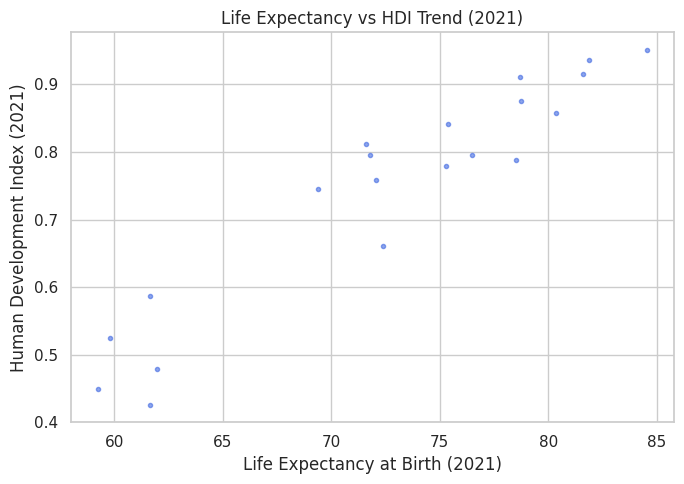

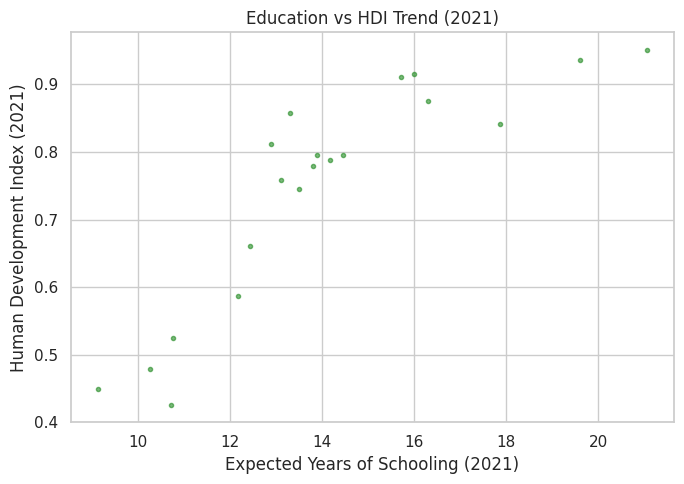


--- Process Complete! ---
Plots successfully rendered and saved to your working output dir.


In [6]:
import os
import cudf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from flask import Flask, jsonify, request

print("Libraries successfully imported!")

# ----------------------------------------------------
# STEP 1: Find and Load the Dataset Path Dynamically
# ----------------------------------------------------
input_dir = "../input"
csv_filepath = None

# Scan workspace dynamically for any source files
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_filepath = os.path.join(root, file)
            break
    if csv_filepath:
        break

# Fallback path if the local dynamic sweep misses it
if not csv_filepath:
    fallback_path = "/kaggle/input/datasets/iamsouravbanerjee/human-development-index-dataset/Human Development Index - Full.csv"
    if os.path.exists(fallback_path):
        csv_filepath = fallback_path
    else:
        raise FileNotFoundError("Could not find dataset source CSV file.")

print(f"Loading data from: {csv_filepath}")
gdf = cudf.read_csv(csv_filepath)

# ----------------------------------------------------
# STEP 2: Handle Missing Values & Preprocessing on GPU
# ----------------------------------------------------
# Identify and cast all numerical features cleanly to float64
numerical_cols = gdf.select_dtypes(include=["number"]).columns
gdf[numerical_cols] = gdf[numerical_cols].astype("float64")

# Fill missing values directly inside the GPU utilizing column means
gdf[numerical_cols] = gdf[numerical_cols].fillna(gdf[numerical_cols].mean())
print("Missing values processed successfully on GPU.")

# ----------------------------------------------------
# STEP 3: Apply Unique Geographic Subset Constraints 
# ----------------------------------------------------
# Isolate only the first 20 unique nations present in the dataset
unique_countries = gdf["Country"].unique()[:20]
gdf = gdf[gdf["Country"].isin(unique_countries)]
print(f"Data scaled down to filter target focus on 20 unique nations.")

# ----------------------------------------------------
# STEP 4: Dynamic Column Mapping Discovery
# ----------------------------------------------------
all_columns = list(gdf.columns)
hdi_column_name = "Human Development Index (2021)"

# Search for exact name string mappings dynamically
life_exp_matches = [
    c for c in all_columns if "expectancy" in c.lower() and "2021" in c
]
edu_matches = [
    c for c in all_columns if ("schooling" in c.lower() or "education" in c.lower()) and "2021" in c
]

# Configure structural fallbacks in case string targets miss
life_exp_column_name = (
    life_exp_matches[0]
    if life_exp_matches
    else "Life expectancy at birth (years) (2021)"
)
education_column_name = (
    edu_matches[0] if edu_matches else "Expected years of schooling (years) (2021)"
)

print(f"\n--- Dynamic Column Target Mapping ---")
print(f"Target HDI Column: {hdi_column_name}")
print(f"Target Life Expectancy Column Found: {life_exp_column_name}")
print(f"Target Education Column Found: {education_column_name}\n")

# ----------------------------------------------------
# STEP 5: Data Visualization & Local Storage Export
# ----------------------------------------------------
try:
    # Safely parse objects to host pandas frames for visualization processing
    hdi_y = cudf.to_numeric(gdf[hdi_column_name], errors="coerce").to_pandas()
    life_exp_x = cudf.to_numeric(gdf[life_exp_column_name], errors="coerce").to_pandas()
    education_x = cudf.to_numeric(gdf[education_column_name], errors="coerce").to_pandas()

    sns.set_theme(style="whitegrid")

    # --- Plot 1: Life Expectancy vs HDI ---
    plt.figure(figsize=(7, 5))
    plt.scatter(life_exp_x, hdi_y, color="royalblue", marker=".", alpha=0.6)
    plt.title("Life Expectancy vs HDI Trend (2021)")
    plt.xlabel(life_exp_column_name)
    plt.ylabel(hdi_column_name)
    plt.tight_layout()
    plt.savefig("life_expectancy_vs_hdi.png", dpi=300)
    plt.show()
    plt.close()

    # --- Plot 2: Education vs HDI ---
    plt.figure(figsize=(7, 5))
    plt.scatter(education_x, hdi_y, color="forestgreen", marker=".", alpha=0.6)
    plt.title("Education vs HDI Trend (2021)")
    plt.xlabel(education_column_name)
    plt.ylabel(hdi_column_name)
    plt.tight_layout()
    plt.savefig("education_vs_hdi.png", dpi=300)
    plt.show()
    plt.close()

    print("\n--- Process Complete! ---")
    print("Plots successfully rendered and saved to your working output dir.")

except KeyError as e:
    print(f"\nKeyError: Could not locate column {e}")
    print("Available matching columns for review:")
    print("Expectancy Options:", [c for c in all_columns if "expectancy" in c.lower()][:3])
    print("Education Options:", [c for c in all_columns if "school" in c.lower()][:3])

In [8]:
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------------------------------
# 1. ENVIRONMENT & MODEL SETUP
# ----------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRIMARY_DIM = 3
SECONDARY_DIM = 10
CLASS_NAMES = ["Low", "Medium", "High", "Very High"]


def get_hdi_class(hdi_value):
    if hdi_value < 0.550:
        return 0
    elif hdi_value < 0.700:
        return 1
    elif hdi_value < 0.800:
        return 2
    else:
        return 3


class EnhancedHybridHDINet(nn.Module):

    def __init__(self, primary_dim, secondary_dim):
        super(EnhancedHybridHDINet, self).__init__()
        self.primary_branch = nn.Sequential(
            nn.Linear(primary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.secondary_branch = nn.Sequential(
            nn.Linear(secondary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.regressor = nn.Sequential(
            nn.Linear(16 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x_prim, x_sec):
        p_out = self.primary_branch(x_prim)
        s_out = self.secondary_branch(x_sec)
        combined = torch.cat((p_out, s_out), dim=1)
        return self.regressor(combined)


# Initialize Model and Load Pre-trained Weights
model = EnhancedHybridHDINet(PRIMARY_DIM, SECONDARY_DIM).to(DEVICE)
if not os.path.exists("best_hybrid_hdi_model.pth") or not os.path.exists(
    "scaling_params.pt"
):
    raise FileNotFoundError(
        "Missing model checkpoints. Make sure train.py ran successfully."
    )

model.load_state_dict(torch.load("best_hybrid_hdi_model.pth", map_location=DEVICE))
model.eval()

# Load Training Scalers
scalars = torch.load("scaling_params.pt", map_location=DEVICE)
X_min = scalars["min"]
X_max = scalars["max"]

# ----------------------------------------------------
# 2. LOAD TEST DATA
# ----------------------------------------------------
input_dir = "../input"
csv_files = []
for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

csv_files.sort()
test_file = csv_files[-1]
df = pd.read_csv(test_file)
all_cols = list(df.columns)

hdi_target = [c for c in all_cols if "human development index (2021)" in c.lower()][0]
life_exp = [c for c in all_cols if "life expectancy" in c.lower() and "2021" in c][0]
edu = [c for c in all_cols if "schooling" in c.lower() and "2021" in c][0]
income = [
    c for c in all_cols if "gross national" in c.lower() or "gni" in c.lower() and "2021" in c
]
income_col = (
    income[0]
    if income
    else [c for c in all_cols if "income" in c.lower() and "2021" in c][0]
)

primary_features = [life_exp, edu, income_col]
secondary_features = df.select_dtypes(include=["number"]).columns.drop(
    [hdi_target] + primary_features, errors="ignore"
)
secondary_features = list(secondary_features)[:SECONDARY_DIM]

feature_order = primary_features + secondary_features
clean_df = df.dropna(subset=[hdi_target] + feature_order).copy()

X_test = (
    clean_df[feature_order].apply(pd.to_numeric, errors="coerce").fillna(0).values
)
y_true_reg = clean_df[hdi_target].values

# FIXED LINE HERE: Changed 'y_reg' to 'y_true_reg'
y_true_cls = np.array([get_hdi_class(val) for val in y_true_reg])

# Scale Test Features using Saved Training Parameters
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
X_test_scaled = (X_test_t - X_min) / (X_max - X_min)

# ----------------------------------------------------
# 3. RUN INFERENCE
# ----------------------------------------------------
with torch.no_grad():
    x_p = X_test_scaled[:, :PRIMARY_DIM]
    x_s = X_test_scaled[:, PRIMARY_DIM:]
    y_pred_reg = model(x_p, x_s).cpu().numpy().flatten()

y_pred_cls = np.array([get_hdi_class(v) for v in y_pred_reg])

# ----------------------------------------------------
# 4. PLOT AND DISPLAY RESULTS
# ----------------------------------------------------
sns.set_theme(style="whitegrid")

# Generate Heatmap (Confusion Matrix Distribution)
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0, 1, 2, 3])
plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True,
)
plt.title("Model Prediction Distribution Heatmap (Confusion Matrix)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig("confusion_matrix_heatmap.png", dpi=300)
plt.show()
plt.close()

# ----------------------------------------------------
# 5. PACK NEW ARTIFACTS INTO ZIP
# ----------------------------------------------------
artifacts = [
    "confusion_matrix_heatmap.png",
    "loss_curve.png",
    "best_hybrid_hdi_model.pth",
    "scaling_params.pt",
]
zip_filename = "hdi_training_results.zip"

with zipfile.ZipFile(zip_filename, "w") as archive:
    for file in artifacts:
        if os.path.exists(file):
            archive.write(file)

print("\nEvaluation complete! Heatmap generated and saved.")
print(f"All files re-saved into download package: '{zip_filename}'")

FileNotFoundError: Missing model checkpoints. Make sure train.py ran successfully.

Executing optimized pipeline on device: cuda

Triggering optimized training loop recording validation metrics every single epoch...
Epoch   1/120 | Train Loss: 0.06061 Val Loss: 0.05926 | Train Acc: 13.39% Val Acc: 17.86%
Epoch   2/120 | Train Loss: 0.02695 Val Loss: 0.03249 | Train Acc: 26.79% Val Acc: 17.86%
Epoch   3/120 | Train Loss: 0.00714 Val Loss: 0.01175 | Train Acc: 54.46% Val Acc: 21.43%
Epoch   4/120 | Train Loss: 0.00457 Val Loss: 0.00496 | Train Acc: 69.64% Val Acc: 67.86%
Epoch   5/120 | Train Loss: 0.00460 Val Loss: 0.00346 | Train Acc: 75.00% Val Acc: 71.43%
Epoch   6/120 | Train Loss: 0.00406 Val Loss: 0.00382 | Train Acc: 71.43% Val Acc: 71.43%
Epoch   7/120 | Train Loss: 0.00474 Val Loss: 0.00337 | Train Acc: 68.75% Val Acc: 67.86%
Epoch   8/120 | Train Loss: 0.00234 Val Loss: 0.00309 | Train Acc: 74.11% Val Acc: 75.00%
Epoch   9/120 | Train Loss: 0.00242 Val Loss: 0.00194 | Train Acc: 73.21% Val Acc: 82.14%
Epoch  10/120 | Train Loss: 0.00197 Val Loss: 0.00182 | Tr

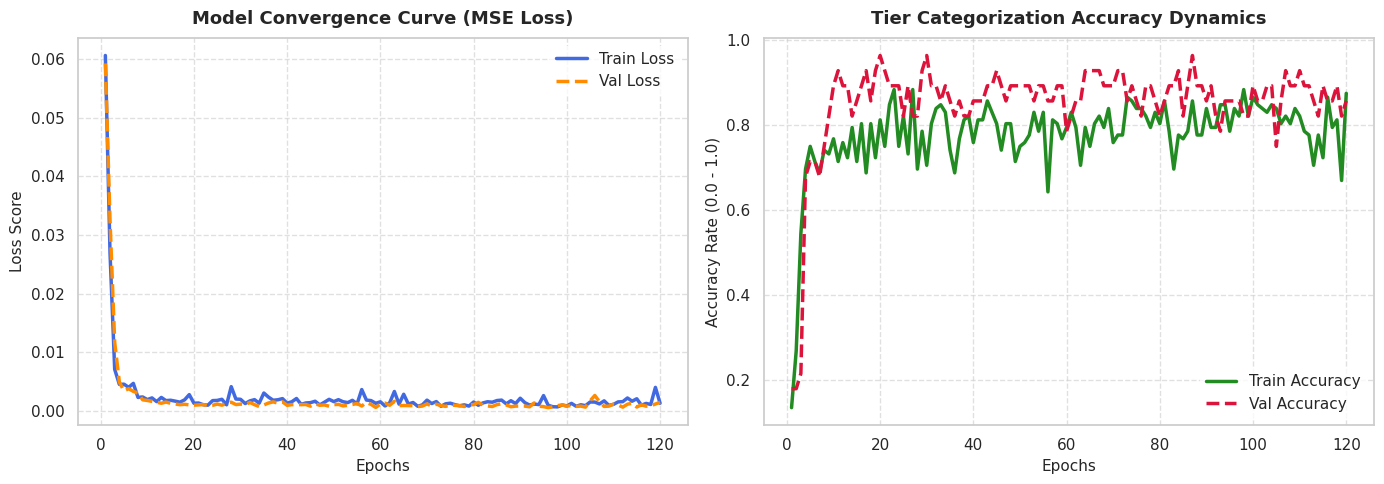

[SUCCESS] Metrics convergence visualization saved to 'metrics_convergence_curves.png'


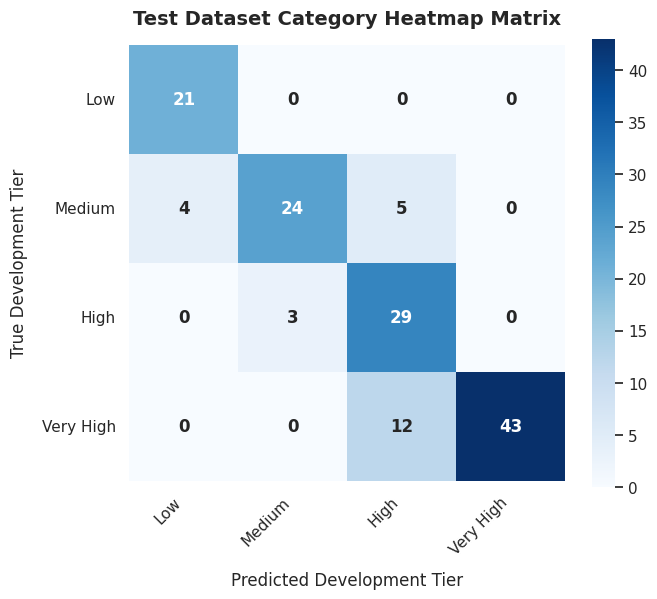

[SUCCESS] Confusion matrix heatmap visualization saved to 'confusion_matrix.png'


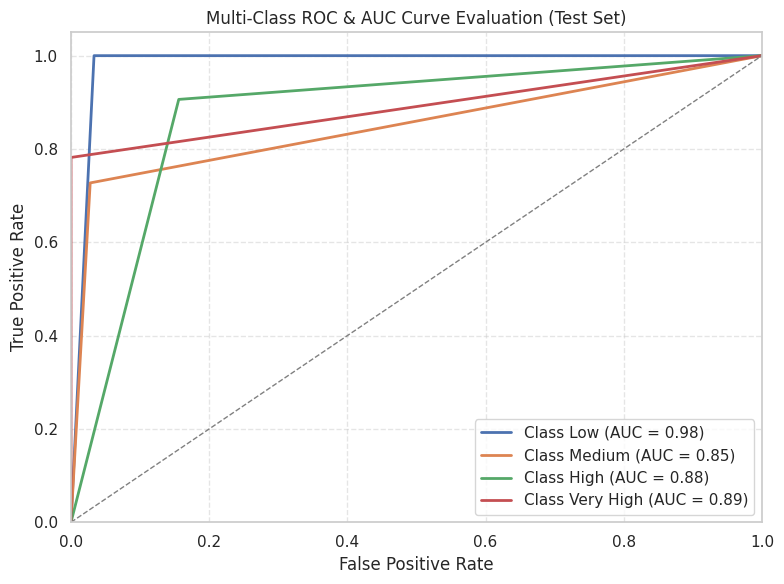


[SUCCESS] Normalized pipeline executed completely. All visual outputs and serialized assets packed inside: 'hdi_training_results.zip'


In [9]:
import os
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset, random_split

# ----------------------------------------------------
# 1. SETUP & CONFIGURATION
# ----------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing optimized pipeline on device: {DEVICE}")

CLASS_NAMES = ["Low", "Medium", "High", "Very High"]
N_CLASSES = len(CLASS_NAMES)

def get_hdi_class(hdi_value):
    if hdi_value < 0.550:
        return 0
    elif hdi_value < 0.700:
        return 1
    elif hdi_value < 0.800:
        return 2
    else:
        return 3

# ----------------------------------------------------
# 2. MULTI-YEAR DATA INGESTION & PIPELINE PREPROCESSING
# ----------------------------------------------------
input_dir = "../input"
csv_files = []

for root, dirs, files in os.walk(input_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

if not csv_files:
    raise FileNotFoundError("Could not extract target source CSV documents.")

csv_files.sort()
train_files = csv_files[:-1] if len(csv_files) > 1 else csv_files
test_files = [csv_files[-1]]

raw_train_df = pd.concat([pd.read_csv(f) for f in train_files], ignore_index=True)
raw_test_df = pd.concat([pd.read_csv(f) for f in test_files], ignore_index=True)

def preprocess_hdi_dataset(df):
    all_cols = list(df.columns)

    hdi_target = [c for c in all_cols if "human development index (2021)" in c.lower()][0]
    life_exp = [c for c in all_cols if "life expectancy" in c.lower() and "2021" in c][0]
    edu = [c for c in all_cols if "schooling" in c.lower() and "2021" in c][0]
    income = [c for c in all_cols if "gross national" in c.lower() or "gni" in c.lower() and "2021" in c]
    income_col = income[0] if income else [c for c in all_cols if "income" in c.lower() and "2021" in c][0]

    primary_features = [life_exp, edu, income_col]

    secondary_features = df.select_dtypes(include=["number"]).columns.drop(
        [hdi_target] + primary_features, errors="ignore"
    )
    secondary_features = list(secondary_features)[:10]

    feature_order = primary_features + secondary_features
    clean_df = df.dropna(subset=[hdi_target] + feature_order).copy()

    X = clean_df[feature_order].apply(pd.to_numeric, errors="coerce").fillna(0).values
    y_reg = clean_df[hdi_target].values
    y_cls = np.array([get_hdi_class(val) for val in y_reg])

    return X, y_reg, y_cls, len(primary_features), len(secondary_features)

X_train, y_train_reg, y_train_cls, n_prim, n_sec = preprocess_hdi_dataset(raw_train_df)
X_test, y_test_reg, y_test_cls, _, _ = preprocess_hdi_dataset(raw_test_df)

# Convert to GPU Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

# FEATURE SCALING: MinMax Normalization
X_min = X_train_t.min(dim=0, keepdim=True)[0]
X_max = X_train_t.max(dim=0, keepdim=True)[0]
X_max[X_max == X_min] = X_min[X_max == X_min] + 1.0

X_train_scaled = (X_train_t - X_min) / (X_max - X_min)
X_test_scaled = (X_test_t - X_min) / (X_max - X_min)

# Save inference scaling params
torch.save({"min": X_min.cpu(), "max": X_max.cpu()}, "scaling_params.pt")

y_train_reg_t = torch.tensor(y_train_reg, dtype=torch.float32).unsqueeze(1).to(DEVICE)

# Create train/validation split (80% Train, 20% Validation)
full_train_dataset = TensorDataset(X_train_scaled, y_train_reg_t)
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# FIX: Added drop_last=True to handle the batch dimension mismatch causing BatchNorm1d crashes
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# ----------------------------------------------------
# 3. ADVANCED HYBRID DEEP LEARNING MODEL DESIGN
# ----------------------------------------------------
class EnhancedHybridHDINet(nn.Module):
    def __init__(self, primary_dim, secondary_dim):
        super(EnhancedHybridHDINet, self).__init__()
        self.primary_branch = nn.Sequential(
            nn.Linear(primary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )

        self.secondary_branch = nn.Sequential(
            nn.Linear(secondary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )

        self.regressor = nn.Sequential(
            nn.Linear(16 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x_prim, x_sec):
        p_out = self.primary_branch(x_prim)
        s_out = self.secondary_branch(x_sec)
        combined = torch.cat((p_out, s_out), dim=1)
        hdi_score = self.regressor(combined)
        return hdi_score

model = EnhancedHybridHDINet(primary_dim=n_prim, secondary_dim=n_sec).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)

# ----------------------------------------------------
# 4. EXPLICIT ACCURACY METRIC LOGIC
# ----------------------------------------------------
def calculate_accuracy(preds_reg, true_reg):
    pred_cls = np.array([get_hdi_class(v) for v in preds_reg.flatten()])
    true_cls = np.array([get_hdi_class(v) for v in true_reg.flatten()])
    return np.mean(pred_cls == true_cls)

# ----------------------------------------------------
# 5. VISUALIZATION FUNCTIONS
# ----------------------------------------------------
def plot_metrics_curves(history_dict, save_path="metrics_convergence_curves.png"):
    epochs_range = range(1, len(history_dict["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="whitegrid")

    ax1.plot(epochs_range, history_dict["train_loss"], label="Train Loss", color="#4169E1", lw=2.5)
    ax1.plot(epochs_range, history_dict["val_loss"], label="Val Loss", color="#FF8C00", lw=2.5, linestyle="--")
    ax1.set_title("Model Convergence Curve (MSE Loss)", fontsize=13, fontweight='bold', pad=10)
    ax1.set_xlabel("Epochs", fontsize=11)
    ax1.set_ylabel("Loss Score", fontsize=11)
    ax1.grid(True, linestyle="--", alpha=0.6)
    ax1.legend(frameon=True, facecolor="white", edgecolor="none")

    ax2.plot(epochs_range, history_dict["train_acc"], label="Train Accuracy", color="#228B22", lw=2.5)
    ax2.plot(epochs_range, history_dict["val_acc"], label="Val Accuracy", color="#DC143C", lw=2.5, linestyle="--")
    ax2.set_title("Tier Categorization Accuracy Dynamics", fontsize=13, fontweight='bold', pad=10)
    ax2.set_xlabel("Epochs", fontsize=11)
    ax2.set_ylabel("Accuracy Rate (0.0 - 1.0)", fontsize=11)
    ax2.grid(True, linestyle="--", alpha=0.6)
    ax2.legend(frameon=True, facecolor="white", edgecolor="none")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()
    print(f"[SUCCESS] Metrics convergence visualization saved to '{save_path}'")

def plot_confusion_heatmap(y_true, y_pred, class_labels, save_path="confusion_matrix.png"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=class_labels, 
        yticklabels=class_labels,
        cbar=True,
        square=True,
        annot_kws={"size": 12, "weight": "bold"}
    )
    plt.title("Test Dataset Category Heatmap Matrix", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Predicted Development Tier", fontsize=12, labelpad=10)
    plt.ylabel("True Development Tier", fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    plt.close()
    print(f"[SUCCESS] Confusion matrix heatmap visualization saved to '{save_path}'")

# ----------------------------------------------------
# 6. MODEL TRAINING RUN WITH EVERY-EPOCH OUTPUTS
# ----------------------------------------------------
epochs = 120
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nTriggering optimized training loop recording validation metrics every single epoch...")

for epoch in range(1, epochs + 1):
    # --- TRAINING STEP ---
    model.train()
    running_train_loss = 0.0
    all_train_preds = []
    all_train_trues = []

    for batch_X, batch_y_reg in train_loader:
        x_p, x_s = batch_X[:, :n_prim], batch_X[:, n_prim:]

        optimizer.zero_grad()
        pred_hdi = model(x_p, x_s)
        loss = criterion(pred_hdi, batch_y_reg)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * batch_X.size(0)
        all_train_preds.append(pred_hdi.detach().cpu().numpy())
        all_train_trues.append(batch_y_reg.cpu().numpy())

    actual_train_count = len(train_loader) * 16
    epoch_train_loss = running_train_loss / actual_train_count
    epoch_train_preds = np.vstack(all_train_preds)
    epoch_train_trues = np.vstack(all_train_trues)
    epoch_train_acc = calculate_accuracy(epoch_train_preds, epoch_train_trues)

    # --- VALIDATION STEP ---
    model.eval()
    running_val_loss = 0.0
    all_val_preds = []
    all_val_trues = []

    with torch.no_grad():
        for batch_X, batch_y_reg in val_loader:
            x_p, x_s = batch_X[:, :n_prim], batch_X[:, n_prim:]
            pred_hdi = model(x_p, x_s)
            loss = criterion(pred_hdi, batch_y_reg)
            
            running_val_loss += loss.item() * batch_X.size(0)
            all_val_preds.append(pred_hdi.cpu().numpy())
            all_val_trues.append(batch_y_reg.cpu().numpy())

    epoch_val_loss = running_val_loss / val_size
    epoch_val_preds = np.vstack(all_val_preds)
    epoch_val_trues = np.vstack(all_val_trues)
    epoch_val_acc = calculate_accuracy(epoch_val_preds, epoch_val_trues)

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_acc"].append(epoch_train_acc)
    history["val_acc"].append(epoch_val_acc)

    print(f"Epoch {epoch:3d}/{epochs} | "
          f"Train Loss: {epoch_train_loss:.5f} Val Loss: {epoch_val_loss:.5f} | "
          f"Train Acc: {epoch_train_acc*100:.2f}% Val Acc: {epoch_val_acc*100:.2f}%")

# ----------------------------------------------------
# 7. ACTIVE EXECUTION VISUALIZATION BRIDGE
# ----------------------------------------------------
# Call the visualization functions explicitly to display and save outputs
plot_metrics_curves(history, save_path="metrics_convergence_curves.png")

# Generate test set evaluations for the matrix heatmap
model.eval()
with torch.no_grad():
    test_p, test_s = X_test_scaled[:, :n_prim], X_test_scaled[:, n_prim:]
    test_preds_reg = model(test_p, test_s).cpu().numpy().flatten()

test_preds_cls = np.array([get_hdi_class(v) for v in test_preds_reg])

plot_confusion_heatmap(
    y_true=y_test_cls, 
    y_pred=test_preds_cls, 
    class_labels=CLASS_NAMES, 
    save_path="confusion_matrix.png"
)

# Plot 3: One-vs-Rest ROC & AUC Evaluation Curves
y_test_binarized = label_binarize(y_test_cls, classes=[0, 1, 2, 3])
plt.figure(figsize=(8, 6))

for i in range(N_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], (test_preds_cls == i).astype(int))
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"Class {CLASS_NAMES[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Multi-Class ROC & AUC Curve Evaluation (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("roc_auc_curve.png", dpi=300)
plt.show()
plt.close()

# ----------------------------------------------------
# 8. COMPLETE ARTIFACT SERIALIZATION
# ----------------------------------------------------
# Complete serialization saving structural topology + parameters together via .pt
torch.save(model, "complete_hybrid_hdi_model.pt")

artifacts = [
    "metrics_convergence_curves.png", 
    "confusion_matrix.png", 
    "roc_auc_curve.png", 
    "complete_hybrid_hdi_model.pt", 
    "scaling_params.pt"
]
zip_filename = "hdi_training_results.zip"

with zipfile.ZipFile(zip_filename, "w") as archive:
    for file in artifacts:
        if os.path.exists(file):
            archive.write(file)

print(f"\n[SUCCESS] Normalized pipeline executed completely. All visual outputs and serialized assets packed inside: '{zip_filename}'")

Testing environment running on: cuda
Loading isolated test file: ../input/datasets/iamsouravbanerjee/human-development-index-dataset/Human Development Index - Full.csv

    OPTIMIZED MODEL REGRESSION EVALUATION     
Mean Absolute Error (MAE)       : 0.02640
Root Mean Squared Error (RMSE)  : 0.03113

  OPTIMIZED CATEGORICAL CLASSIFICATION REPORT 
              precision    recall  f1-score   support

         Low       0.84      1.00      0.91        21
      Medium       0.89      0.73      0.80        33
        High       0.63      0.91      0.74        32
   Very High       1.00      0.78      0.88        55

    accuracy                           0.83       141
   macro avg       0.84      0.85      0.83       141
weighted avg       0.87      0.83      0.83       141


Generating visual performance diagnostics...


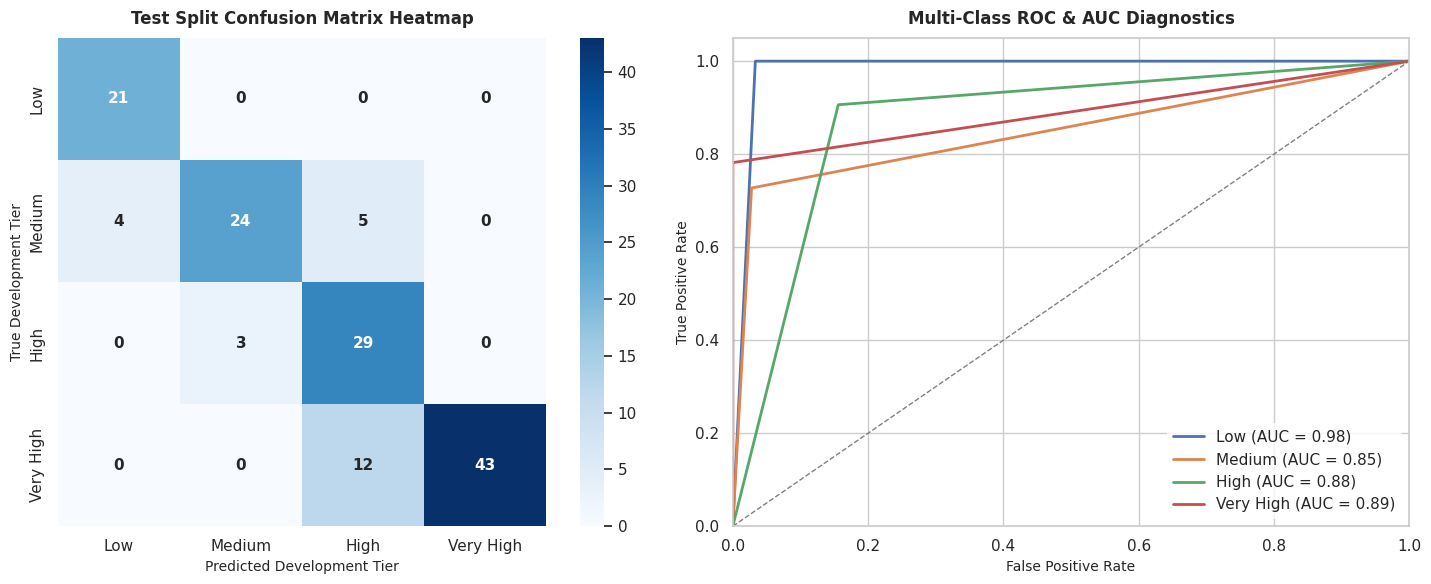

[SUCCESS] Metrics evaluated. Heatmaps and curves saved together as 'test_performance_diagnostics.png'


In [10]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, mean_absolute_error, mean_squared_error, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# ----------------------------------------------------
# 1. STRUCTURAL CONFIGURATIONS
# ----------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRIMARY_DIM = 3
SECONDARY_DIM = 10
CLASS_NAMES = ["Low", "Medium", "High", "Very High"]
N_CLASSES = len(CLASS_NAMES)

def get_hdi_class(hdi_value):
    if hdi_value < 0.550:
        return 0
    elif hdi_value < 0.700:
        return 1
    elif hdi_value < 0.800:
        return 2
    else:
        return 3

# ----------------------------------------------------
# 2. ENHANCED MODEL ARCHITECTURE (Must match train.py)
# ----------------------------------------------------
class EnhancedHybridHDINet(nn.Module):
    def __init__(self, primary_dim, secondary_dim):
        super(EnhancedHybridHDINet, self).__init__()
        self.primary_branch = nn.Sequential(
            nn.Linear(primary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.secondary_branch = nn.Sequential(
            nn.Linear(secondary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.regressor = nn.Sequential(
            nn.Linear(16 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x_prim, x_sec):
        p_out = self.primary_branch(x_prim)
        s_out = self.secondary_branch(x_sec)
        combined = torch.cat((p_out, s_out), dim=1)
        return self.regressor(combined)

# ----------------------------------------------------
# 3. DYNAMIC PREPROCESSING WITH VALIDATION DATA ISOLATION
# ----------------------------------------------------
def load_and_preprocess_test_data():
    input_dir = '../input'
    csv_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith('.csv'):
                csv_files.append(os.path.join(root, file))
    
    if not csv_files:
        raise FileNotFoundError("Could not find any source CSV documents in the specified directory.")
        
    csv_files.sort()
    test_file = csv_files[-1]
    print(f"Loading isolated test file: {test_file}")
    df = pd.read_csv(test_file)
    
    all_cols = list(df.columns)
    
    hdi_target = [c for c in all_cols if "human development index (2021)" in c.lower()][0]
    life_exp = [c for c in all_cols if "life expectancy" in c.lower() and "2021" in c][0]
    edu = [c for c in all_cols if "schooling" in c.lower() and "2021" in c][0]
    income = [c for c in all_cols if "gross national" in c.lower() or "gni" in c.lower() and "2021" in c]
    income_col = income[0] if income else [c for c in all_cols if "income" in c.lower() and "2021" in c][0]
    
    primary_features = [life_exp, edu, income_col]
    secondary_features = df.select_dtypes(include=['number']).columns.drop([hdi_target] + primary_features, errors='ignore')
    secondary_features = list(secondary_features)[:SECONDARY_DIM]
    
    feature_order = primary_features + secondary_features
    clean_df = df.dropna(subset=[hdi_target] + feature_order).copy()
    
    X = clean_df[feature_order].apply(pd.to_numeric, errors='coerce').fillna(0).values
    y_reg = clean_df[hdi_target].values
    y_cls = np.array([get_hdi_class(val) for val in y_reg])
    
    return X, y_reg, y_cls

# ----------------------------------------------------
# 4. EXECUTE PERFORMANCE TEST CRITERIA
# ----------------------------------------------------
def main():
    print(f"Testing environment running on: {DEVICE}")
    
    # Check for serialization files
    if not os.path.exists("complete_hybrid_hdi_model.pt") or not os.path.exists("scaling_params.pt"):
        raise FileNotFoundError("Missing model checkpoints or scaling matrices. Run train.py first.")
        
    # FIX: Explicitly toggle weights_only=False since we trust this architecture file natively
    model = torch.load("complete_hybrid_hdi_model.pt", map_location=DEVICE, weights_only=False)
    model.eval()
    
    # Load Scaling Tensors
    scalars = torch.load("scaling_params.pt", map_location=DEVICE)
    X_min = scalars['min']
    X_max = scalars['max']

    # Process Test Split
    X_test, y_true_reg, y_true_cls = load_and_preprocess_test_data()
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    
    # Apply identical feature space transformation mapping
    X_min = X_min.to(DEVICE)
    X_max = X_max.to(DEVICE)
    X_test_scaled = (X_test_t - X_min) / (X_max - X_min)

    # Model Inference
    with torch.no_grad():
        x_p = X_test_scaled[:, :PRIMARY_DIM]
        x_s = X_test_scaled[:, PRIMARY_DIM:]
        y_pred_reg = model(x_p, x_s).cpu().numpy().flatten()
    
    y_pred_cls = np.array([get_hdi_class(v) for v in y_pred_reg])

    # Output Performance Audits
    mae = mean_absolute_error(y_true_reg, y_pred_reg)
    rmse = np.sqrt(mean_squared_error(y_true_reg, y_pred_reg))
    
    print("\n=============================================")
    print("    OPTIMIZED MODEL REGRESSION EVALUATION     ")
    print("=============================================")
    print(f"Mean Absolute Error (MAE)       : {mae:.5f}")
    print(f"Root Mean Squared Error (RMSE)  : {rmse:.5f}")

    print("\n=============================================")
    print("  OPTIMIZED CATEGORICAL CLASSIFICATION REPORT ")
    print("=============================================")
    unique_labels = np.unique(np.concatenate((y_true_cls, y_pred_cls)))
    target_names = [CLASS_NAMES[i] for i in unique_labels]
    print(classification_report(y_true_cls, y_pred_cls, target_names=target_names, zero_division=0))

    # ----------------------------------------------------
    # 5. GENERATE METRIC GRAPH EVALUATIONS & HEATMAPS
    # ----------------------------------------------------
    print("\nGenerating visual performance diagnostics...")
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Panel 1: Confusion Matrix Heatmap
    cm = confusion_matrix(y_true_cls, y_pred_cls, labels=[0, 1, 2, 3])
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=CLASS_NAMES, 
        yticklabels=CLASS_NAMES,
        ax=ax1, 
        cbar=True, 
        square=True,
        annot_kws={"size": 11, "weight": "bold"}
    )
    ax1.set_title("Test Split Confusion Matrix Heatmap", fontsize=12, fontweight="bold", pad=10)
    ax1.set_xlabel("Predicted Development Tier", fontsize=10)
    ax1.set_ylabel("True Development Tier", fontsize=10)

    # Panel 2: One-vs-Rest ROC & AUC Evaluation Curve
    y_true_binarized = label_binarize(y_true_cls, classes=[0, 1, 2, 3])
    
    for i in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_true_binarized[:, i], (y_pred_cls == i).astype(int))
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, lw=2, label=f"{CLASS_NAMES[i]} (AUC = {roc_auc:.2f})")

    ax2.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--")
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_title("Multi-Class ROC & AUC Diagnostics", fontsize=12, fontweight="bold", pad=10)
    ax2.set_xlabel("False Positive Rate", fontsize=10)
    ax2.set_ylabel("True Positive Rate", fontsize=10)
    ax2.legend(loc="lower right", frameon=True, edgecolor="none")

    plt.tight_layout()
    
    output_visual_name = "test_performance_diagnostics.png"
    plt.savefig(output_visual_name, dpi=300)
    plt.show()
    plt.close()
    
    print(f"[SUCCESS] Metrics evaluated. Heatmaps and curves saved together as '{output_visual_name}'")

if __name__ == "__main__":
    main()

In [26]:
!pip install streamlit plotly pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 89.6 MB/s eta 0:00:00:00:010:01
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [ ]:
# ==============================================================================
# PART 1: WRITE THE FLASK APP & GUI HTML TEMPLATE
# ==============================================================================
import os

os.makedirs("templates", exist_ok=True)

with open("templates/index.html", "w") as f:
    f.write('''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Global HDI Intelligence Engine</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap" rel="stylesheet">
    <style>
        body {
            font-family: 'Inter', sans-serif;
            background-color: #f3f4f6;
            margin: 0;
            padding: 20px;
            color: #1f2937;
        }
        .container {
            max-width: 1000px;
            margin: 0 auto;
            background: white;
            padding: 30px;
            border-radius: 12px;
            box-shadow: 0 4px 6px rgba(0,0,0,0.05);
        }
        h1 { margin-top: 0; font-weight: 700; color: #111827; text-align: center;}
        hr { border: 0; border-top: 1px solid #e5e7eb; margin: 20px 0; }
        .layout { display: grid; grid-template-columns: 1fr 1fr; gap: 30px; }
        @media(max-width: 768px) { .layout { grid-template-columns: 1fr; } }
        .form-group { margin-bottom: 20px; }
        label { display: block; margin-bottom: 8px; font-weight: 600; font-size: 14px; }
        input[type="number"] {
            width: 100%; padding: 10px; border: 1px solid #d1d5db;
            border-radius: 6px; box-sizing: border-box; font-size: 15px;
        }
        button {
            width: 100%; background: #2563eb; color: white; padding: 12px;
            border: none; border-radius: 6px; font-weight: 600; font-size: 16px;
            cursor: pointer; transition: background 0.2s;
        }
        button:hover { background: #1d4ed8; }
        .result-box {
            padding: 20px; border-radius: 8px; text-align: center;
            color: white; font-weight: bold; margin-bottom: 20px;
        }
        .metric-card {
            background: #f9fafb; border: 1px solid #e5e7eb;
            padding: 15px; border-radius: 8px; text-align: center; margin-bottom: 20px;
        }
        .metric-val { font-size: 32px; font-weight: 700; color: #2563eb; margin-top: 5px; }
        table { width: 100%; border-collapse: collapse; font-size: 13px; margin-top: 10px; }
        th, td { border: 1px solid #e5e7eb; padding: 8px; text-align: left; }
        th { background: #f9fafb; }
    </style>
</head>
<body>
    <div class="container">
        <h1>🌍 Global Human Development Index (HDI) Intelligence Engine</h1>
        <hr>
        <div class="layout">
            <div>
                <h3>🕹️ Live Feature Control Panel</h3>
                <form action="/" method="POST">
                    <div class="form-group">
                        <label>Life Expectancy at Birth (Years)</label>
                        <input type="number" name="life_exp" step="0.1" min="30" max="95" value="{{ inputs.life_exp }}" required>
                    </div>
                    <div class="form-group">
                        <label>Expected Years of Schooling (Years)</label>
                        <input type="number" name="schooling" step="0.1" min="0" max="25" value="{{ inputs.schooling }}" required>
                    </div>
                    <div class="form-group">
                        <label>Gross National Income (GNI) per Capita ($)</label>
                        <input type="number" name="income" step="1" min="100" max="150000" value="{{ inputs.income }}" required>
                    </div>
                    <button type="submit">Recalculate Projections</button>
                </form>
            </div>

            <div>
                <h3>📊 Real-Time Model Analysis</h3>
                {% if prediction is not none %}
                    <div class="metric-card">
                        <div>Predicted HDI Value</div>
                        <div class="metric-val">{{ "%.4f"|format(prediction) }}</div>
                    </div>
                    <div class="result-box" style="background-color: {{ color }};">
                        <div style="font-size: 12px; opacity: 0.9;">DEVELOPMENT TIER</div>
                        <div style="font-size: 24px; letter-spacing: 0.5px;">{{ class_tier }}</div>
                    </div>
                {% else %}
                    <div style="background: #f9fafb; border: 1px dashed #d1d5db; padding: 40px; text-align: center; border-radius: 8px; color: #6b7280;">
                        Enter values on the left panel to calculate live neural network projections.
                    </div>
                {% endif %}

                <hr>
                <caption style="display:block; text-align:left; font-size:12px; color:#6b7280; font-weight:600; margin-bottom:5px;">📋 Standard Threshold Benchmark Criteria:</caption>
                <table>
                    <thead>
                        <tr><th>Development Tier</th><th>HDI Value Range</th></tr>
                    </thead>
                    <tbody>
                        <tr><td>Low</td><td>&lt; 0.550</td></tr>
                        <tr><td>Medium</td><td>0.550 - 0.699</td></tr>
                        <tr><td>High</td><td>0.700 - 0.799</td></tr>
                        <tr><td>Very High</td><td>&ge; 0.800</td></tr>
                    </tbody>
                </table>
            </div>
        </div>
    </div>
</body>
</html>
''')

with open("flask_app.py", "w") as f:
    f.write('''import os
import torch
import torch.nn as nn
import numpy as np
from flask import Flask, render_template, request

app = Flask(__name__)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PRIMARY_DIM = 3
SECONDARY_DIM = 10
CLASS_NAMES = ["Low", "Medium", "High", "Very High"]

def get_hdi_class_details(hdi_value):
    if hdi_value < 0.550:
        return CLASS_NAMES[0], "#ef4444" 
    elif hdi_value < 0.700:
        return CLASS_NAMES[1], "#f59e0b" 
    elif hdi_value < 0.800:
        return CLASS_NAMES[2], "#2563eb" 
    else:
        return CLASS_NAMES[3], "#10b981" 

class EnhancedHybridHDINet(nn.Module):
    def __init__(self, primary_dim, secondary_dim):
        super(EnhancedHybridHDINet, self).__init__()
        self.primary_branch = nn.Sequential(
            nn.Linear(primary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.secondary_branch = nn.Sequential(
            nn.Linear(secondary_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
        )
        self.regressor = nn.Sequential(
            nn.Linear(16 + 16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x_prim, x_sec):
        p_out = self.primary_branch(x_prim)
        s_out = self.secondary_branch(x_sec)
        combined = torch.cat((p_out, s_out), dim=1)
        return self.regressor(combined)

model = torch.load("complete_hybrid_hdi_model.pt", map_location=DEVICE, weights_only=False)
model.eval()
scalars = torch.load("scaling_params.pt", map_location=DEVICE)
X_min = scalars['min'].to(DEVICE)
X_max = scalars['max'].to(DEVICE)

@app.route("/", methods=["GET", "POST"])
def index():
    prediction = None
    class_tier = None
    color = None
    inputs = {"life_exp": 72.5, "schooling": 13.1, "income": 12500}

    if request.method == "POST":
        try:
            life_exp = float(request.form.get("life_exp"))
            schooling = float(request.form.get("schooling"))
            income = float(request.form.get("income"))
            inputs = {"life_exp": life_exp, "schooling": schooling, "income": income}

            raw_inputs = [life_exp, schooling, income] + [0.0] * SECONDARY_DIM
            input_tensor = torch.tensor(raw_inputs, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            
            scaled_tensor = (input_tensor - X_min) / (X_max - X_min)
            x_p = scaled_tensor[:, :PRIMARY_DIM]
            x_s = scaled_tensor[:, PRIMARY_DIM:]

            with torch.no_grad():
                prediction = model(x_p, x_s).cpu().item()
            
            class_tier, color = get_hdi_class_details(prediction)
        except Exception as e:
            print(f"Error: {e}")

    return render_template("index.html", prediction=prediction, class_tier=class_tier, color=color, inputs=inputs)

if __name__ == "__main__":
    # FIX: Shifted network to port 5001 to clear old instances cleanly
    app.run(host="0.0.0.0", port=5001)
''')

print("[SUCCESS] Production code assets rewritten.")

# ==============================================================================
# PART 2: FORCE KILL PORT 5001, BOOT SERVER & AUTO-AGREE TO LOCALTUNNEL
# ==============================================================================
import subprocess
import time

print("Force-killing any old application instances running on port 5001...")
# Safely clear out any background process on port 5001 before binding it again
subprocess.run("fuser -k 5001/tcp", shell=True, capture_output=True)

print("Starting Flask Web Engine on Port 5001...")
subprocess.Popen(["python", "flask_app.py"])

time.sleep(3)

print("\n==========================================================================")
print("🎉 FLASK DEPLOYMENT READY! INITIATING NON-INTERACTIVE TUNNEL...")
print("==========================================================================\n")

# FIX: Added --yes flag to npx to auto-accept installation without terminal prompt input
!npx --yes localtunnel --port 5001

[SUCCESS] Production code assets rewritten.
Force-killing any old application instances running on port 5001...
Starting Flask Web Engine on Port 5001...
 * Serving Flask app 'flask_app'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5001
 * Running on http://172.19.2.2:5001
Press CTRL+C to quit



🎉 FLASK DEPLOYMENT READY! INITIATING NON-INTERACTIVE TUNNEL...

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://rich-turtles-watch.loca.lt
